In [1]:
# PyTorch and torchvision
import torch
import torchvision

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# 1. 데이터 준비


In [10]:
!wget "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar" -P ~/work/data_augmentation/data
!tar -xf ~/work/data_augmentation/data/images.tar -C ~/work/data_augmentation/data/

--2026-07-30 05:33:53--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/root/work/data_augmentation/data/images.tar’

images.tar          100%[===================>] 756.82M  2.03MB/s    in 3m 42s  

2026-07-30 05:37:36 (3.41 MB/s) - ‘/root/work/data_augmentation/data/images.tar’ saved [793579520/793579520]



In [11]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, random_split

# 이미지 정규화 및 크기 조정
def get_transform(mode="baseline"):

    if mode == "baseline":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])

    elif mode == "aug1":     # 기하학적 변환
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])

    elif mode == "aug2":     # 색상 변환
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3,
                saturation=0.3,
                hue=0.1
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])

In [12]:
dataset_dir = "~/work/data_augmentation/data/Images/"

# transform 없이 먼저 읽기
base_dataset = ImageFolder(dataset_dir)

# train : test = 8 : 2
train_size = int(len(base_dataset) * 0.8)
test_size = len(base_dataset) - train_size

train_subset, test_subset = random_split(
    base_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
    )

train_indices = train_subset.indices
test_indices = test_subset.indices

- 모델마다 다른 loader 사용

In [13]:
def build_loader(indices,
                 transform,
                 dataset_dir,
                 batch_size=32,
                 shuffle=False):

    dataset = ImageFolder(
        dataset_dir,
        transform=transform
    )

    subset = Subset(dataset, indices)

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False
    )

    return loader

In [14]:
baseline_train_loader = build_loader(
    train_indices,
    get_transform("baseline"),
    dataset_dir,
    batch_size=32,
    shuffle=True
)

In [15]:
aug_train_loader1 = build_loader(
    train_indices,
    get_transform("aug1"),
    dataset_dir,
    batch_size=32,
    shuffle=True
)

In [16]:
aug_train_loader2 = build_loader(
    train_indices,
    get_transform("aug2"),
    dataset_dir,
    batch_size=32,
    shuffle=True
)

In [17]:
test_loader = build_loader(
    test_indices,
    get_transform("baseline"),
    dataset_dir,
    batch_size=32,
    shuffle=False
)

In [18]:
ds_info = {
    "class_names": base_dataset.classes,
    "num_classes": len(base_dataset.classes)
}

# 2. MixUp / CutMix 함수 정의

get_clip_box : CutMix에서 자를 영역 계산

In [19]:
def get_clip_box(image):
    _, H, W = image.shape

    # 크롭 영역의 기준이 될 중심점 좌표 (x, y)를 무작위로 선택
    x = torch.randint(0, W, (1,)).item()
    y = torch.randint(0, H, (1,)).item()

    # 바운딩 박스의 너비와 높이 결정 (최소 1px 보장)
    width = max(1, int(W * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(H * torch.sqrt(1 - torch.rand(1)).item()))

    # 중심점과 크기를 기준으로 좌표 계산
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(W, x + width // 2 + 1)
    y_max = min(H, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

cutmix
- get_clip_box를 활용하여 배치 단위로 CutMix를 적용
- 레이블 손실을 계산할 수 있도록 관련 변수를 함께 반환
- 배치 내에서 이미지마다 적용되는 패치는 다르지만 패치의 위치가 모두 동일

In [20]:
def cutmix(images, labels):
    rand_index = torch.randperm(images.size(0)).to(images.device)

    x1, y1, x2, y2 = get_clip_box(images[0])

    mixed_images = images.clone()
    # 바운딩 박스에 무작위로 섞은(rand_index) 이미지 패치를 덮어씌움
    mixed_images[:, :, y1:y2, x1:x2] = images[rand_index, :, y1:y2, x1:x2]

    # 원본 이미지의 남은 비율(lam) 계산
    cut_area = (x2 - x1) * (y2 - y1)
    total_area = images.size(2) * images.size(3)
    lam = 1 - cut_area / total_area

    return mixed_images, labels, labels[rand_index], lam

mixup : 배치 단위로 MixUp을 적용

In [21]:
def mixup(images, labels, alpha=1.0):
  # 섞을 비율 설정
  lam = np.random.beta(alpha, alpha)
  lam = max(lam, 1 - lam)

  rand_index = torch.randperm(images.size(0)).to(images.device)

  # 두 이미지를 비율에 따라 투명하게 합성
  mixed_images = lam * images + (1 - lam) * images[rand_index]

  # 원본 레이블과 섞인 이미지의 레이블 분리
  labels_a = labels
  labels_b = labels[rand_index]

  return mixed_images, labels_a, labels_b, lam

# 3. 모델 불러오기
- baseline_model : 원본 이미지로 학습
- aug_model1 : 기본 증강(기하학적 변환)을 적용한 이미지로 학습
- aug_model2 : 기본 증강(색상 변환)을 적용한 이미지로 학습
- mixup_model : MixUp을 적용한 이미지로 학습
- cutmix_model : CutMix를 적용한 이미지로 학습

In [22]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])

def create_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

baseline_model  = create_resnet50(num_classes).to(device)
aug_model1      = create_resnet50(num_classes).to(device)
aug_model2      = create_resnet50(num_classes).to(device)
mixup_model     = create_resnet50(num_classes).to(device)
cutmix_model    = create_resnet50(num_classes).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


In [23]:
criterion = nn.CrossEntropyLoss()

baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=1e-4
)

aug_optimizer1 = torch.optim.Adam(
    aug_model1.parameters(),
    lr=1e-4
)

aug_optimizer2 = torch.optim.Adam(
    aug_model2.parameters(),
    lr=1e-4
)

mixup_optimizer = torch.optim.Adam(
    mixup_model.parameters(),
    lr=1e-4
)

cutmix_optimizer = torch.optim.Adam(
    cutmix_model.parameters(),
    lr=1e-4
)

# 4. Training Loop

train_one_epoch
- baseline_model, aug_model에서 1에폭을 학습하는 함수

In [24]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)    # 배치 전체 손실 계산을 위해 배치 크기 곱함

        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

train_one_epoch_mixup
- mixup_model에서 1에폭을 학습하는 함수

In [25]:
def train_one_epoch_mixup(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        images, labels_a, labels_b, lam = mixup(images, labels)

        optimizer.zero_grad()

        outputs = model(images)

        loss = (
            lam * criterion(outputs, labels_a)
            + (1 - lam) * criterion(outputs, labels_b)
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        correct += (
            lam * (predicted == labels_a).sum().item()
            + (1 - lam) * (predicted == labels_b).sum().item()
        )
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

train_one_epoch_cutmix
- cutmix_model에서 1에폭을 학습하는 함수

In [26]:
def train_one_epoch_cutmix(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        images, labels_a, labels_b, lam = cutmix(images, labels)

        optimizer.zero_grad()

        outputs = model(images)

        loss = (
            lam * criterion(outputs, labels_a)
            + (1 - lam) * criterion(outputs, labels_b)
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        correct += (
            lam * (predicted == labels_a).sum().item()
            + (1 - lam) * (predicted == labels_b).sum().item()
        )
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

validate
- 증강을 적용하지 않은 test data를 이용해 모델의 성능을 측정하는 함수

In [27]:
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

fit
- 여러 epoch 동안 train_one_epoch()와 validate()를 반복 호출하고 결과를 저장하는 함수

In [28]:
import os

def fit(model, train_loader, val_loader,
        criterion, optimizer,
        device, epochs,
        train_fn=train_one_epoch,
        save_dir=None):

  if save_dir is not None:
    os.makedirs(save_dir, exist_ok=True)

  history = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": []
      }

  for epoch in range(epochs):
    train_loss, train_acc = train_fn(
        model,
        train_loader,
        criterion,
        optimizer,
        device
        )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
        )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
        )

    if save_dir is not None:
      torch.save({
          "epoch": epoch + 1,
          "model_state_dict": model.state_dict(),
          "optimizer_state_dict": optimizer.state_dict(),
          "history": history
          }, os.path.join(save_dir, f"epoch_{epoch+1}.pth"))

  return history

# 5. 모델 학습하기

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
epochs = 10

In [ ]:
aug_history1 = fit(
    model=aug_model1,
    train_loader=aug_train_loader1,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=aug_optimizer1,
    device=device,
    epochs=epochs,
    train_fn=train_one_epoch,
    save_dir="/content/drive/MyDrive/checkpoints/aug1"
)

Epoch [1/10] Train Loss: 1.8961 Train Acc: 0.5584 Val Loss: 0.9880 Val Acc: 0.7174
Epoch [2/10] Train Loss: 0.8996 Train Acc: 0.7386 Val Loss: 0.8678 Val Acc: 0.7374
Epoch [3/10] Train Loss: 0.6771 Train Acc: 0.7960 Val Loss: 0.9591 Val Acc: 0.7172
Epoch [4/10] Train Loss: 0.5594 Train Acc: 0.8263 Val Loss: 0.8701 Val Acc: 0.7405
Epoch [5/10] Train Loss: 0.4578 Train Acc: 0.8560 Val Loss: 0.8771 Val Acc: 0.7456
Epoch [6/10] Train Loss: 0.3898 Train Acc: 0.8768 Val Loss: 0.8844 Val Acc: 0.7434
Epoch [7/10] Train Loss: 0.3432 Train Acc: 0.8935 Val Loss: 1.0137 Val Acc: 0.7216
Epoch [8/10] Train Loss: 0.3053 Train Acc: 0.9017 Val Loss: 0.9448 Val Acc: 0.7422
Epoch [9/10] Train Loss: 0.2497 Train Acc: 0.9222 Val Loss: 0.9307 Val Acc: 0.7512
Epoch [10/10] Train Loss: 0.2489 Train Acc: 0.9189 Val Loss: 1.0272 Val Acc: 0.7296


In [ ]:
aug_history2 = fit(
    model=aug_model2,
    train_loader=aug_train_loader2,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=aug_optimizer2,
    device=device,
    epochs=epochs,
    train_fn=train_one_epoch,
    save_dir="/content/drive/MyDrive/checkpoints/aug2"
)

Epoch [1/10] Train Loss: 1.8433 Train Acc: 0.5722 Val Loss: 1.0167 Val Acc: 0.7007
Epoch [2/10] Train Loss: 0.8217 Train Acc: 0.7598 Val Loss: 0.8807 Val Acc: 0.7296
Epoch [3/10] Train Loss: 0.5620 Train Acc: 0.8288 Val Loss: 0.8195 Val Acc: 0.7473
Epoch [4/10] Train Loss: 0.4257 Train Acc: 0.8680 Val Loss: 0.8822 Val Acc: 0.7490
Epoch [5/10] Train Loss: 0.3081 Train Acc: 0.9045 Val Loss: 0.8924 Val Acc: 0.7473
Epoch [6/10] Train Loss: 0.2820 Train Acc: 0.9115 Val Loss: 0.9579 Val Acc: 0.7342
Epoch [7/10] Train Loss: 0.2153 Train Acc: 0.9329 Val Loss: 0.9604 Val Acc: 0.7464
Epoch [8/10] Train Loss: 0.1757 Train Acc: 0.9489 Val Loss: 0.9402 Val Acc: 0.7529
Epoch [9/10] Train Loss: 0.1774 Train Acc: 0.9450 Val Loss: 1.1705 Val Acc: 0.7070
Epoch [10/10] Train Loss: 0.1729 Train Acc: 0.9483 Val Loss: 1.0756 Val Acc: 0.7310


In [24]:
baseline_history = fit(
    model=baseline_model,
    train_loader=baseline_train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=baseline_optimizer,
    device=device,
    epochs=epochs,
    train_fn=train_one_epoch,
    save_dir="/content/drive/MyDrive/checkpoints/baseline"
)

Epoch [1/10] Train Loss: 1.7265 Train Acc: 0.5997 Val Loss: 0.9657 Val Acc: 0.7155
Epoch [2/10] Train Loss: 0.6039 Train Acc: 0.8247 Val Loss: 0.8374 Val Acc: 0.7485
Epoch [3/10] Train Loss: 0.3247 Train Acc: 0.9056 Val Loss: 0.9249 Val Acc: 0.7306
Epoch [4/10] Train Loss: 0.1978 Train Acc: 0.9457 Val Loss: 0.9095 Val Acc: 0.7444
Epoch [5/10] Train Loss: 0.1655 Train Acc: 0.9532 Val Loss: 1.0328 Val Acc: 0.7281
Epoch [6/10] Train Loss: 0.1335 Train Acc: 0.9643 Val Loss: 1.0947 Val Acc: 0.7165
Epoch [7/10] Train Loss: 0.1274 Train Acc: 0.9648 Val Loss: 1.1651 Val Acc: 0.7094
Epoch [8/10] Train Loss: 0.1057 Train Acc: 0.9722 Val Loss: 1.0467 Val Acc: 0.7408
Epoch [9/10] Train Loss: 0.0923 Train Acc: 0.9738 Val Loss: 1.2447 Val Acc: 0.7077
Epoch [10/10] Train Loss: 0.1104 Train Acc: 0.9665 Val Loss: 1.3111 Val Acc: 0.6876


In [25]:
mixup_history = fit(
    model=mixup_model,
    train_loader=baseline_train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=mixup_optimizer,
    device=device,
    epochs=epochs,
    train_fn=train_one_epoch_mixup,
    save_dir="/content/drive/MyDrive/checkpoints/mixup"
)

Epoch [1/10] Train Loss: 3.0733 Train Acc: 0.3698 Val Loss: 1.2438 Val Acc: 0.6752
Epoch [2/10] Train Loss: 2.4468 Train Acc: 0.5092 Val Loss: 1.0866 Val Acc: 0.7109
Epoch [3/10] Train Loss: 2.2986 Train Acc: 0.5485 Val Loss: 1.0489 Val Acc: 0.7281
Epoch [4/10] Train Loss: 2.1529 Train Acc: 0.5907 Val Loss: 1.0309 Val Acc: 0.7371
Epoch [5/10] Train Loss: 2.0472 Train Acc: 0.6226 Val Loss: 1.0152 Val Acc: 0.7471
Epoch [6/10] Train Loss: 1.9400 Train Acc: 0.6533 Val Loss: 0.9890 Val Acc: 0.7476
Epoch [7/10] Train Loss: 1.8769 Train Acc: 0.6659 Val Loss: 1.0112 Val Acc: 0.7471
Epoch [8/10] Train Loss: 1.9152 Train Acc: 0.6575 Val Loss: 1.0686 Val Acc: 0.7340
Epoch [9/10] Train Loss: 1.8672 Train Acc: 0.6702 Val Loss: 1.0746 Val Acc: 0.7242
Epoch [10/10] Train Loss: 1.8244 Train Acc: 0.6747 Val Loss: 1.1063 Val Acc: 0.7408


In [26]:
cutmix_history = fit(
    model=cutmix_model,
    train_loader=baseline_train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=cutmix_optimizer,
    device=device,
    epochs=epochs,
    train_fn=train_one_epoch_cutmix,
    save_dir="/content/drive/MyDrive/checkpoints/cutmix"
)

Epoch [1/10] Train Loss: 3.2503 Train Acc: 0.3180 Val Loss: 1.1627 Val Acc: 0.6902
Epoch [2/10] Train Loss: 2.4841 Train Acc: 0.4701 Val Loss: 1.0506 Val Acc: 0.7245
Epoch [3/10] Train Loss: 2.3015 Train Acc: 0.5027 Val Loss: 0.9993 Val Acc: 0.7281
Epoch [4/10] Train Loss: 2.1114 Train Acc: 0.5532 Val Loss: 0.9224 Val Acc: 0.7634
Epoch [5/10] Train Loss: 2.0230 Train Acc: 0.5674 Val Loss: 0.9646 Val Acc: 0.7549
Epoch [6/10] Train Loss: 1.9036 Train Acc: 0.5950 Val Loss: 1.0305 Val Acc: 0.7359
Epoch [7/10] Train Loss: 1.8386 Train Acc: 0.6047 Val Loss: 0.9496 Val Acc: 0.7561
Epoch [8/10] Train Loss: 1.8221 Train Acc: 0.6067 Val Loss: 0.9794 Val Acc: 0.7556
Epoch [9/10] Train Loss: 1.7037 Train Acc: 0.6348 Val Loss: 1.0279 Val Acc: 0.7641
Epoch [10/10] Train Loss: 1.6757 Train Acc: 0.6296 Val Loss: 0.9791 Val Acc: 0.7655


# 6. 결과 시각화 하기

- aug_model1, aug_model2 비교하기

In [4]:
import matplotlib.pyplot as plt

def plot_aug_comparison(aug_history1, aug_history2):

    epochs = range(1, len(aug_history1["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, aug_history1["val_loss"], marker='o', label="Aug1 (Flip + Rotation)")
    plt.plot(epochs, aug_history2["val_loss"], marker='s', label="Aug2 (Flip + ColorJitter)")
    plt.title("Validation Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, aug_history1["val_acc"], marker='o', label="Aug1 (Flip + Rotation)")
    plt.plot(epochs, aug_history2["val_acc"], marker='s', label="Aug2 (Flip + ColorJitter)")
    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

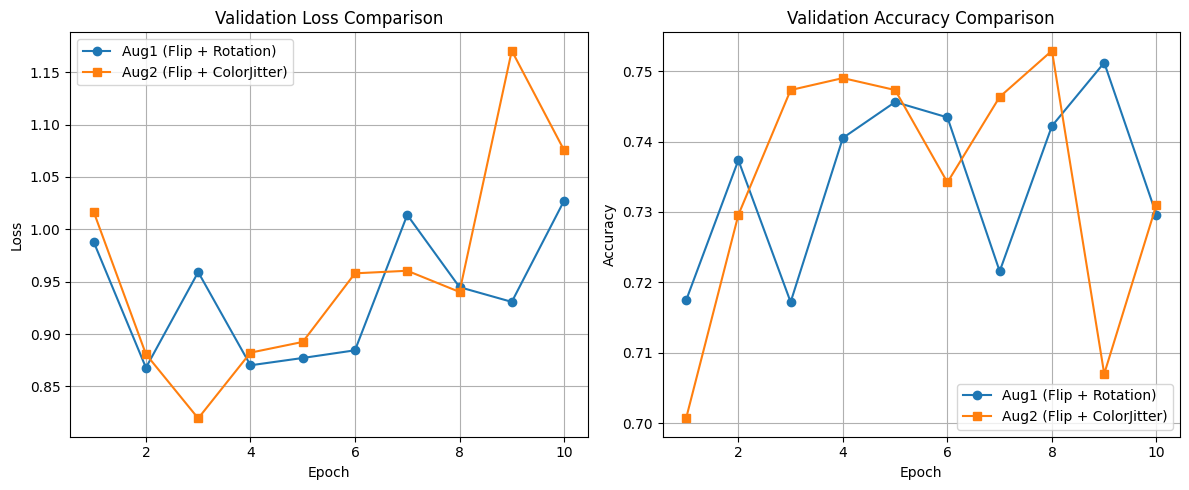

In [5]:
import torch

ckpt1 = torch.load("/content/drive/MyDrive/checkpoints/aug1/epoch_10.pth")
ckpt2 = torch.load("/content/drive/MyDrive/checkpoints/aug2/epoch_10.pth")

aug_history1 = ckpt1["history"]
aug_history2 = ckpt2["history"]

plot_aug_comparison(aug_history1, aug_history2)

- 전체 모델 비교하기

In [6]:
import matplotlib.pyplot as plt

def plot_history(baseline_history,
                 aug_history1,
                 aug_history2,
                 mixup_history,
                 cutmix_history):

    epochs = range(1, len(baseline_history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, baseline_history["val_loss"], label="Baseline")
    plt.plot(epochs, aug_history1["val_loss"], label="Aug1 (Flip + Rotation)")
    plt.plot(epochs, aug_history2["val_loss"], label="Aug2 (Flip + ColorJitter)")
    plt.plot(epochs, mixup_history["val_loss"], label="MixUp")
    plt.plot(epochs, cutmix_history["val_loss"], label="CutMix")
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, baseline_history["val_acc"], label="Baseline")
    plt.plot(epochs, aug_history1["val_acc"], label="Aug1 (Flip + Rotation)")
    plt.plot(epochs, aug_history2["val_acc"], label="Aug2 (Flip + ColorJitter)")
    plt.plot(epochs, mixup_history["val_acc"], label="MixUp")
    plt.plot(epochs, cutmix_history["val_acc"], label="CutMix")
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

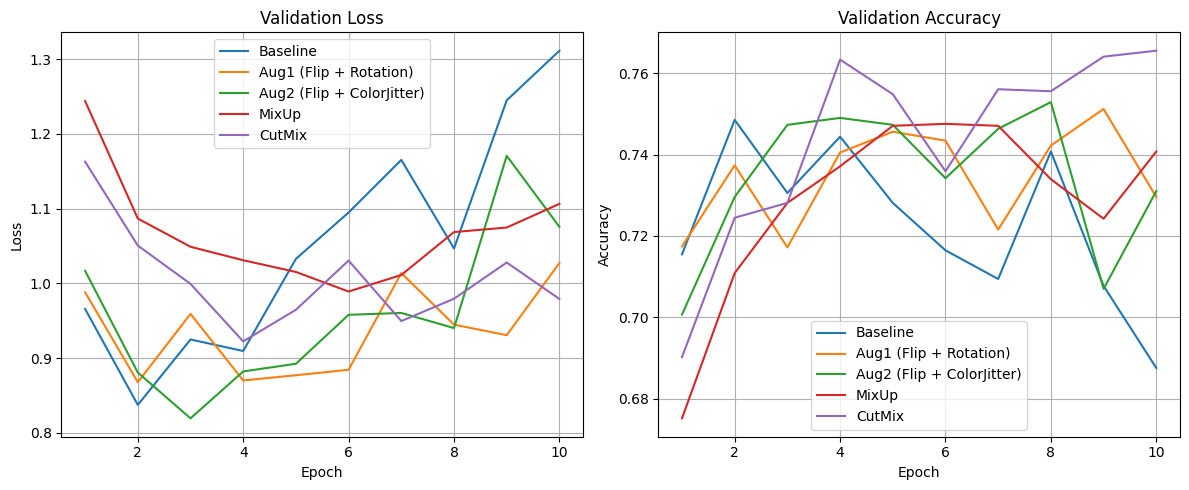

In [7]:
import torch

ckpt1 = torch.load("/content/drive/MyDrive/checkpoints/aug1/epoch_10.pth")
ckpt2 = torch.load("/content/drive/MyDrive/checkpoints/aug2/epoch_10.pth")
ckpt3 = torch.load("/content/drive/MyDrive/checkpoints/baseline/epoch_10.pth")
ckpt4 = torch.load("/content/drive/MyDrive/checkpoints/cutmix/epoch_10.pth")
ckpt5 = torch.load("/content/drive/MyDrive/checkpoints/mixup/epoch_10.pth")

aug_history1 = ckpt1["history"]
aug_history2 = ckpt2["history"]
baseline_history = ckpt3["history"]
cutmix_history = ckpt4["history"]
mixup_history = ckpt5["history"]

plot_history(
    baseline_history,
    aug_history1,
    aug_history2,
    mixup_history,
    cutmix_history
)

# 7. 결과 해석

In [9]:
import pandas as pd

# history 추출
aug_history1 = ckpt1["history"]
aug_history2 = ckpt2["history"]
baseline_history = ckpt3["history"]
cutmix_history = ckpt4["history"]
mixup_history = ckpt5["history"]

# 마지막 epoch 성능 표
result = pd.DataFrame({
    "Model": [
        "Baseline",
        "Aug1 (Flip+Rotation)",
        "Aug2 (Flip+ColorJitter)",
        "MixUp",
        "CutMix"
    ],
    "Train Loss": [
        baseline_history["train_loss"][-1],
        aug_history1["train_loss"][-1],
        aug_history2["train_loss"][-1],
        mixup_history["train_loss"][-1],
        cutmix_history["train_loss"][-1],
    ],
    "Train Acc": [
        baseline_history["train_acc"][-1],
        aug_history1["train_acc"][-1],
        aug_history2["train_acc"][-1],
        mixup_history["train_acc"][-1],
        cutmix_history["train_acc"][-1],
    ],
    "Val Loss": [
        baseline_history["val_loss"][-1],
        aug_history1["val_loss"][-1],
        aug_history2["val_loss"][-1],
        mixup_history["val_loss"][-1],
        cutmix_history["val_loss"][-1],
    ],
    "Val Acc": [
        baseline_history["val_acc"][-1],
        aug_history1["val_acc"][-1],
        aug_history2["val_acc"][-1],
        mixup_history["val_acc"][-1],
        cutmix_history["val_acc"][-1],
    ],
})


result = result.round(4)

result

,Model,Train Loss,Train Acc,Val Loss,Val Acc
0,Baseline,0.1104,0.9665,1.3111,0.6876
1,Aug1 (Flip+Rotation),0.2489,0.9189,1.0272,0.7296
2,Aug2 (Flip+ColorJitter),0.1729,0.9483,1.0756,0.7310
3,MixUp,1.8244,0.6747,1.1063,0.7408
4,CutMix,1.6757,0.6296,0.9791,0.7655


## 실험 결과 분석

ResNet50을 이용하여 **Baseline, Augmentation 1(Flip + Rotation), Augmentation 2(Flip + ColorJitter), MixUp, CutMix**의 성능을 비교하였다.

### 1. Baseline

Baseline 모델은 **Train Accuracy가 96.65%**로 가장 높은 수준을 보였지만, **Validation Accuracy는 68.76%**로 가장 낮았다. 또한 Validation Loss가 **1.3111**로 가장 크게 나타났다. 이는 **과적합(Overfitting)**이 발생했음을 의미한다.

### 2. Data Augmentation

두 가지 데이터 증강 기법 모두 Baseline보다 일반화 성능이 향상되었다.

* **Augmentation 1 (Flip + Rotation)**

  * Validation Accuracy : **72.96%**
  * Validation Loss : **1.0272**

* **Augmentation 2 (Flip + ColorJitter)**

  * Validation Accuracy : **73.10%**
  * Validation Loss : **1.0756**

Augmentation 2는 Validation Accuracy가 약간 더 높았으며(73.10%), Augmentation 1은 Validation Loss가 조금 더 낮았다(1.0272). 두 방법의 성능 차이는 크지 않았지만, **최종 정확도 기준으로는 Augmentation 2가 약간 우수한 결과**를 보였다.

### 3. MixUp

MixUp은 Train Accuracy가 **67.47%**로 낮게 나타났지만 Validation Accuracy는 **74.08%**로 Augmentation보다 높은 성능을 보였다. 이는 MixUp이 학습 데이터를 혼합하여 모델이 어려운 학습 환경에서 학습하도록 만들기 때문에 학습 정확도는 낮아질 수 있지만 일반화 성능은 향상될 수 있음을 보여준다.

### 4. CutMix

CutMix는 **Validation Accuracy가 76.55%**로 모든 실험 중 가장 높은 성능을 기록하였다. 또한 Validation Loss도 **0.9791**로 가장 낮게 나타났다.

반면 Train Accuracy는 **62.96%**로 가장 낮았지만, 이는 CutMix가 학습 과정에서 이미지를 서로 섞어 학습하기 때문에 Train Accuracy 자체가 낮게 측정되는 특성이 반영된 결과이다. 따라서 Train Accuracy가 낮다고 해서 성능이 낮은 것은 아니며, Validation 성능을 기준으로 평가하는 것이 적절하다.

## 결론

Validation Accuracy를 기준으로 모델의 성능을 비교한 결과는 다음과 같다.

| 순위 | 방법                                  | Validation Accuracy |
| -- | ----------------------------------- | ------------------: |
| 1  | CutMix                              |          **76.55%** |
| 2  | MixUp                               |          **74.08%** |
| 3  | Augmentation 2 (Flip + ColorJitter) |          **73.10%** |
| 4  | Augmentation 1 (Flip + Rotation)    |          **72.96%** |
| 5  | Baseline                            |          **68.76%** |

실험 결과, 시간 상 충분한 에포크를 수행하지 못하여 모든 모델이 완전히 수렴하지 못했지만 10번째 에포크를 기준으로 **CutMix가 가장 우수한 일반화 성능을 보였으며**, 단순 데이터 증강보다 MixUp과 CutMix와 같은 데이터 혼합 기반 증강 기법이 모델의 성능 향상에 더욱 효과적임을 확인할 수 있었다. 또한 Baseline은 높은 Train Accuracy에도 불구하고 Validation Accuracy가 가장 낮아 과적합이 발생한 것으로 판단된다.